# Data Import, EDA, PCA and Dataset Export


- Load data bằng TDC `DrugRes`.
- EDA dữ liệu thô.
- Cold split train/validation/test theo cell line.
- Tạo feature từ cell line vector và drug SMILES.
- Scale, PCA và lưu dữ liệu để các model khác dùng lại.

In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tdc.multi_pred import DrugRes
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)

## 1. Load Data

In [4]:
data = DrugRes(name = 'GDSC1', path='../data')
df = data.get_data()
df.head()

Downloading...
100%|██████████| 140M/140M [00:14<00:00, 9.42MiB/s] 
Loading...
Done!


,Drug_ID,Drug,Cell Line_ID,Cell Line,Y
0,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,MC-CAR,"[3.23827250519154, 2.98225419469807, 10.235490...",2.395685
1,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES3,"[8.690197905033282, 3.0914731119366, 9.9924871...",3.140923
2,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES5,"[8.233101127037282, 2.82468731112752, 10.01588...",3.968757
3,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,ES7,"[8.33346622426757, 3.9667571228514302, 9.79399...",2.692768
4,Erlotinib,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,EW-11,"[8.39134072442845, 2.9683601858810698, 10.2606...",2.478678


In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (177310, 5)
Columns: ['Drug_ID', 'Drug', 'Cell Line_ID', 'Cell Line', 'Y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177310 entries, 0 to 177309
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Drug_ID       177310 non-null  object 
 1   Drug          177310 non-null  object 
 2   Cell Line_ID  177310 non-null  object 
 3   Cell Line     177310 non-null  object 
 4   Y             177310 non-null  float64
dtypes: float64(1), object(4)
memory usage: 6.8+ MB


## 2. EDA dễ giải thích

Phần này trả lời 4 câu hỏi chính:

1. Dataset có bao nhiêu mẫu, bao nhiêu drug, bao nhiêu cell line?
2. Target `Y` phân phối như thế nào?
3. Dữ liệu có missing value không?
4. Có bị lệch phân phối theo drug hoặc cell line không?

Các ý này đủ để giải thích trong báo cáo trước khi chuyển sang split, feature engineering và model.

In [6]:
def fast_nunique(series):
    # Cac cot vector nhu `Cell Line` chua numpy.ndarray nen nunique truc tiep se loi va rat cham.
    # Voi EDA, ta khong can dem unique bang toan bo vector; dung ID tuong ung la du de giai thich.
    if series.name == 'Cell Line' and 'Cell Line_ID' in df.columns:
        return df['Cell Line_ID'].nunique()
    if series.name == 'Drug' and 'Drug_ID' in df.columns:
        return df['Drug_ID'].nunique()

    sample = series.dropna().head(5)
    has_vector_value = sample.map(lambda x: isinstance(x, (np.ndarray, list))).any()
    if has_vector_value:
        return 'vector column'

    return series.nunique(dropna=True)

eda_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": [fast_nunique(df[col]) for col in df.columns],
}).sort_values("missing_pct", ascending=False)

eda_summary

,dtype,missing,missing_pct,unique
Drug_ID,object,0,0.0,208
Drug,object,0,0.0,208
Cell Line_ID,object,0,0.0,958
Cell Line,object,0,0.0,958
Y,float64,0,0.0,174195


In [7]:
n_samples = len(df)
n_drugs = df["Drug_ID"].nunique()
n_cells = df["Cell Line_ID"].nunique()
y_stats = df["Y"].describe()
missing_total = int(df.isna().sum().sum())
missing_cols = int((df.isna().sum() > 0).sum())

cell_counts = df["Cell Line_ID"].value_counts()
drug_counts = df["Drug_ID"].value_counts()

print("DATASET OVERVIEW")
print(f"- Dataset co {n_samples:,} mau drug-cell response.")
print(f"- Co {n_drugs:,} drugs va {n_cells:,} cell lines.")
print(f"- Moi mau gom drug, cell line va response Y can du doan.")
print()

print("TARGET Y")
print(f"- Mean: {y_stats['mean']:.3f}")
print(f"- Std:  {y_stats['std']:.3f}")
print(f"- Min:  {y_stats['min']:.3f}")
print(f"- 25%:  {y_stats['25%']:.3f}")
print(f"- 50%:  {y_stats['50%']:.3f}")
print(f"- 75%:  {y_stats['75%']:.3f}")
print(f"- Max:  {y_stats['max']:.3f}")
print("=> Y la bien lien tuc, nen day la bai toan regression.")
print()

print("MISSING VALUES")
if missing_total == 0:
    print("- Khong co missing value trong dataframe goc.")
else:
    print(f"- Co {missing_total:,} missing values nam trong {missing_cols} cot.")
    print("- Can xu ly missing truoc khi train model.")
print()

print("DATA IMBALANCE")
print(f"- Cell line xuat hien nhieu nhat co {cell_counts.iloc[0]:,} mau; median la {cell_counts.median():.0f} mau/cell line.")
print(f"- Drug xuat hien nhieu nhat co {drug_counts.iloc[0]:,} mau; median la {drug_counts.median():.0f} mau/drug.")
print("=> So mau moi drug/cell line khong deu, nen can split can than de tranh leakage va danh gia qua lac quan.")

DATASET OVERVIEW
- Dataset co 177,310 mau drug-cell response.
- Co 208 drugs va 958 cell lines.
- Moi mau gom drug, cell line va response Y can du doan.

TARGET Y
- Mean: 2.007
- Std:  2.715
- Min:  -9.933
- 25%:  0.588
- 50%:  2.460
- 75%:  3.908
- Max:  12.359
=> Y la bien lien tuc, nen day la bai toan regression.

MISSING VALUES
- Khong co missing value trong dataframe goc.

DATA IMBALANCE
- Cell line xuat hien nhieu nhat co 221 mau; median la 182 mau/cell line.
- Drug xuat hien nhieu nhat co 1,837 mau; median la 894 mau/drug.
=> So mau moi drug/cell line khong deu, nen can split can than de tranh leakage va danh gia qua lac quan.


### Cách giải thích nhanh

- `Drug_ID` là mã thuốc, `Drug` là chuỗi SMILES mô tả cấu trúc hóa học của thuốc.
- `Cell Line_ID` là mã dòng tế bào, `Cell Line` là vector đặc trưng sinh học của dòng tế bào.
- `Y` là giá trị response cần dự đoán, vì là số liên tục nên bài toán là **regression**.
- Nếu một số drug/cell line xuất hiện nhiều hơn hẳn các drug/cell line khác, model có thể học tốt hơn trên nhóm phổ biến và kém hơn trên nhóm hiếm.
- Vì vậy notebook dùng `cold_split` theo `Cell Line_ID` để đánh giá khả năng dự đoán trên cell line mới tốt hơn so với random split thông thường.

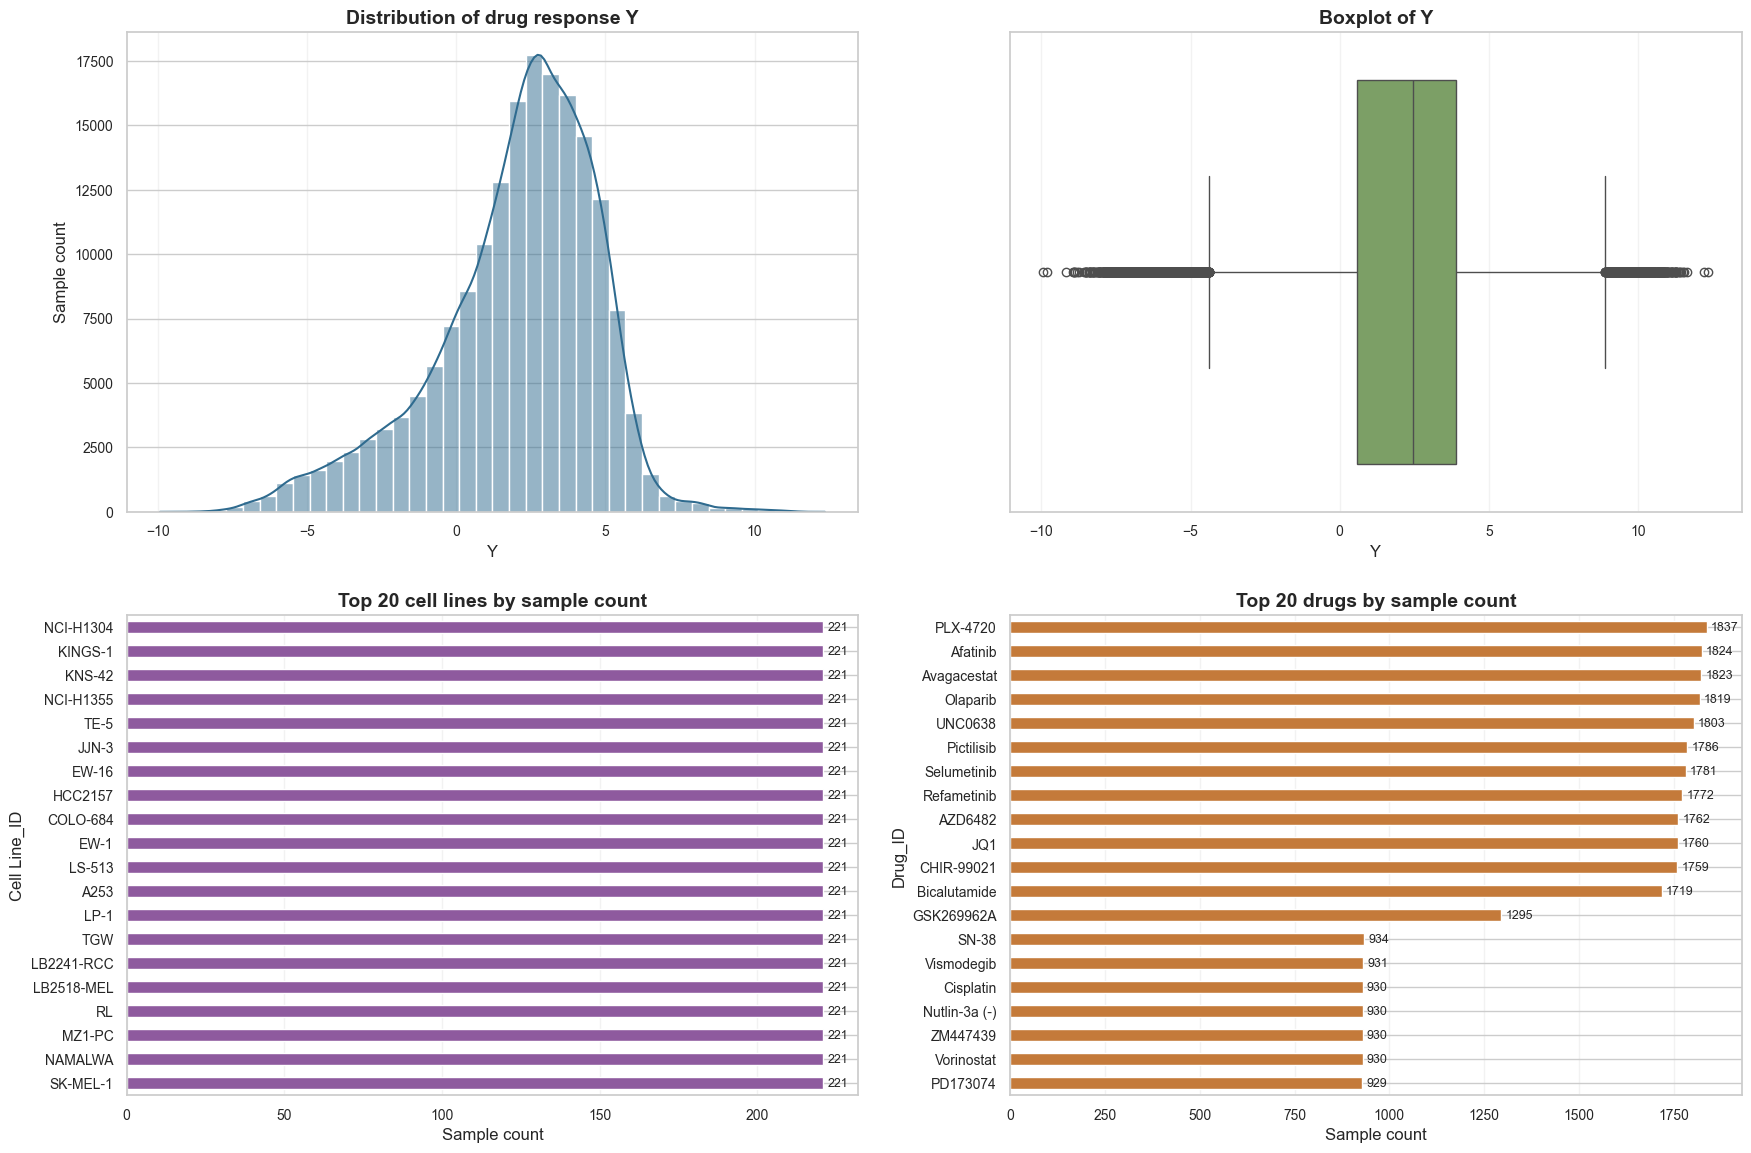

Unique cell lines: 958
Unique drugs: 208
Total samples: 177310


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(df["Y"], kde=True, bins=40, color="#2F6B8F", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of drug response Y", fontsize=14, weight="bold")
axes[0, 0].set_xlabel("Y")
axes[0, 0].set_ylabel("Sample count")

sns.boxplot(x=df["Y"], color="#7AA95C", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Y", fontsize=14, weight="bold")
axes[0, 1].set_xlabel("Y")

cell_counts = df["Cell Line_ID"].value_counts().head(20).sort_values()
cell_counts.plot(kind="barh", color="#8E5A9E", ax=axes[1, 0])
axes[1, 0].set_title("Top 20 cell lines by sample count", fontsize=14, weight="bold")
axes[1, 0].set_xlabel("Sample count")
axes[1, 0].set_ylabel("Cell Line_ID")

for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, padding=3, fontsize=9)

drug_counts = df["Drug_ID"].value_counts().head(20).sort_values()
drug_counts.plot(kind="barh", color="#C47A3A", ax=axes[1, 1])
axes[1, 1].set_title("Top 20 drugs by sample count", fontsize=14, weight="bold")
axes[1, 1].set_xlabel("Sample count")
axes[1, 1].set_ylabel("Drug_ID")

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, padding=3, fontsize=9)

for ax in axes.ravel():
    ax.grid(axis="x", alpha=0.25)
    ax.tick_params(labelsize=10)

plt.tight_layout(pad=2.0)
plt.show()

print("Unique cell lines:", df["Cell Line_ID"].nunique())
print("Unique drugs:", df["Drug_ID"].nunique())
print("Total samples:", len(df))

In [9]:
# Response trung binh theo drug/cell line de xem nhanh do kho cua bai toan.
display(df.groupby("Drug_ID")["Y"].agg(["count", "mean", "std"]).sort_values("count", ascending=False).head(10))
display(df.groupby("Cell Line_ID")["Y"].agg(["count", "mean", "std"]).sort_values("count", ascending=False).head(10))

,count,mean,std
Drug_ID,,,
PLX-4720,1837,3.902058,1.263866
Afatinib,1824,2.057927,2.002777
Avagacestat,1823,4.131865,0.973503
Olaparib,1819,3.554388,1.015721
UNC0638,1803,3.221344,1.418155
Pictilisib,1786,1.041389,1.379910
Selumetinib,1781,2.046957,1.683505
Refametinib,1772,1.629584,1.724104
AZD6482,1762,2.340748,1.333561


,count,mean,std
Cell Line_ID,,,
COLO-684,221,1.974432,2.642950
NAMALWA,221,1.102007,2.739671
NCI-H1304,221,2.664322,2.377451
TC-71,221,1.702333,2.570034
NCI-H1355,221,2.237119,2.985396
LS-513,221,2.325266,2.394221
COR-L95,221,2.979284,2.187905
EW-16,221,1.208911,2.893175
LB2518-MEL,221,2.026252,2.706998


## 3. Train / Validation / Test Split

Dùng cold split theo `Cell Line_ID` giống notebook LGBM để cell line ở test ít bị lẫn với train.

In [10]:
split = data.get_split(
    method='cold_split',
    column_name='Cell Line_ID',
    seed=42,
    frac=[0.7, 0.1, 0.2],
)

train_df = split['train'].reset_index(drop=True)
val_df = split['valid'].reset_index(drop=True)
test_df = split['test'].reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")

Train: (124407, 5)
Val:   (17732, 5)
Test:  (35171, 5)


## 4. Biến đổi dữ liệu

1. Drug SMILES -> Morgan fingerprint 1024 bit.
2. Cell line vector -> scale bằng `StandardScaler`.
3. Fit PCA trên unique cell line của train, giữ 95% variance.
4. Ghép fingerprint drug + PCA cell line thành ma trận `X`.
5. Target là `y = Y`.

In [11]:
import gc

MORGAN_BITS = 1024
RANDOM_STATE = 42
OUTPUT_DIR = Path('../processed_data/model_ready')
ARTIFACT_DIR = OUTPUT_DIR / 'artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def smiles_to_fp(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(MORGAN_BITS, dtype=np.int8)
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=MORGAN_BITS), dtype=np.int8)
    except Exception:
        return np.zeros(MORGAN_BITS, dtype=np.int8)

## 5. PCA cho cell line features

Chỉ fit scaler và PCA trên **train** để tránh data leakage. Sau đó dùng scaler/PCA này transform toàn bộ cell line.

In [12]:
train_unique_cells = train_df.drop_duplicates(subset=['Cell Line_ID'])
train_matrix = np.array([np.array(val, dtype=np.float32) for val in train_unique_cells['Cell Line'].values])

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_matrix)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca.fit(train_scaled)

print(f"PCA hoàn tất: giữ lại {pca.n_components_} chiều, giải thích {np.sum(pca.explained_variance_ratio_):.2%} phương sai.")

all_unique_df = df.drop_duplicates(subset=['Cell Line_ID'])
all_ids = all_unique_df['Cell Line_ID'].values
all_matrix = np.array([np.array(val, dtype=np.float32) for val in all_unique_df['Cell Line'].values])

all_pca_feats = pca.transform(scaler.transform(all_matrix))
cell_pca_map = {cid: feat for cid, feat in zip(all_ids, all_pca_feats)}

joblib.dump(scaler, ARTIFACT_DIR / 'cell_line_scaler.joblib')
joblib.dump(pca, ARTIFACT_DIR / 'cell_line_pca.joblib')

print("Unique train cell lines:", len(train_unique_cells))
print("All unique cell lines:", len(all_unique_df))
print("Cell PCA feature size:", pca.n_components_)

del train_matrix, train_scaled, all_matrix, all_unique_df, all_pca_feats
gc.collect()

PCA hoàn tất: giữ lại 531 chiều, giải thích 95.01% phương sai.
Unique train cell lines: 670
All unique cell lines: 958
Cell PCA feature size: 531


120

## 6. Tạo `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`


```text
X = [drug fingerprint 1024 chiều] + [cell line PCA features]
y = Y
```

In [13]:
def build_dataset(target_df, pca_map):
    drug_feats = np.array([smiles_to_fp(s) for s in target_df['Drug'].values], dtype=np.int8)
    cell_feats = np.array([pca_map[cid] for cid in target_df['Cell Line_ID'].values], dtype=np.float32)
    X = np.hstack([drug_feats, cell_feats])
    y = target_df['Y'].values.astype(np.float32)

    del drug_feats, cell_feats
    gc.collect()
    return X, y

print("Đang tạo ma trận X, y...")
X_train, y_train = build_dataset(train_df, cell_pca_map)
X_val, y_val = build_dataset(val_df, cell_pca_map)
X_test, y_test = build_dataset(test_df, cell_pca_map)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

Đang tạo ma trận X, y...
X_train: (124407, 1555) y_train: (124407,)
X_val:   (17732, 1555) y_val:   (17732,)
X_test:  (35171, 1555) y_test:  (35171,)


## 8. Lưu dữ liệu để model khác dùng lại

Lưu dạng `.npz` Người sau có thể load lại bằng `np.load(...)` và train bất kỳ model nào.

In [14]:
np.savez_compressed(
    OUTPUT_DIR / 'gdsc1_lgbm_style_data.npz',
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
)

metadata = {
    'dataset': 'GDSC1',
    'split_method': 'cold_split by Cell Line_ID',
    'random_state': RANDOM_STATE,
    'drug_feature': f'Morgan fingerprint {MORGAN_BITS} bits',
    'cell_feature': 'StandardScaler + PCA fitted on train cell lines only',
    'cell_pca_components': int(pca.n_components_),
    'X_train_shape': list(X_train.shape),
    'X_val_shape': list(X_val.shape),
    'X_test_shape': list(X_test.shape),
    'saved_npz': str(OUTPUT_DIR / 'gdsc1_lgbm_style_data.npz'),
}

with open(ARTIFACT_DIR / 'gdsc1_lgbm_style_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

{
  "dataset": "GDSC1",
  "split_method": "cold_split by Cell Line_ID",
  "random_state": 42,
  "drug_feature": "Morgan fingerprint 1024 bits",
  "cell_feature": "StandardScaler + PCA fitted on train cell lines only",
  "cell_pca_components": 531,
  "X_train_shape": [
    124407,
    1555
  ],
  "X_val_shape": [
    17732,
    1555
  ],
  "X_test_shape": [
    35171,
    1555
  ],
  "saved_npz": "../processed_data/model_ready/gdsc1_lgbm_style_data.npz"
}


In [15]:
# Smoke test: load lai file vua luu.
loaded = np.load(OUTPUT_DIR / 'gdsc1_lgbm_style_data.npz')
print('Saved arrays:', loaded.files)
print('Loaded X_train:', loaded['X_train'].shape)
print('Loaded y_train:', loaded['y_train'].shape)

Saved arrays: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
Loaded X_train: (124407, 1555)
Loaded y_train: (124407,)
